In [ ]:
### 1. CARGA Y EXPLORACION DE LOS DATOS
# Cargar el dataset de aperturas de ajedrez desde Kaggle
import kagglehub

# Este archivo puede ser descargado desde la siguiente direccion publica: https://www.kaggle.com/datasets/alexandrelemercier/all-chess-openings?select=openings.csv
# A rigor de verdad, he descargado el file para manipularlo de modo directo en mi ambiente local pero se puede utilizar de otro modo. Esto es, online
path = kagglehub.dataset_download("alexandrelemercier/all-chess-openings") # Ruta al dataset


Using Colab cache for faster access to the 'all-chess-openings' dataset.


In [ ]:
!%pip install mlxtend
# Importar librerías necesarias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D

# Evitar warnings innecesarios
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Configurar visualizaciones
sns.set_theme(style="whitegrid")
%matplotlib inline

/bin/bash: line 1: fg: no job control


In [ ]:
df = pd.read_csv('/content/sample_data/openings.csv') # He agregado el dataSet para poder ser visualizado desde aqui

# Realizar un muestreo de las primeras instancias
df.head(20)

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
2,2,"Alekhine Defense, Exchange Variation",white,6485,B03,2018-07-06,2244,2194,40.8,27.7,...,Nd5,d4,d6,c4,Nb6,40.8,31.5,1.295238,2645.880,2042.775
3,3,"Alekhine Defense, Four Pawns Attack",white,881,B03,2018-06-20,2187,2130,39.7,23.2,...,Nd5,d4,d6,c4,Nb6,39.7,37.1,1.070081,349.757,326.851
4,4,"Alekhine Defense, Four Pawns Attack, Fianchett...",black,259,B03,2018-05-20,2122,2178,37.8,21.2,...,Nd5,d4,d6,c4,Nb6,40.9,37.8,1.082011,105.931,97.902
5,5,"Alekhine Defense, Four Pawns Attack, Main Line",white,1207,B03,2018-07-01,2243,2190,41.0,25.9,...,Nd5,d4,d6,c4,Nb6,41.0,33.1,1.238671,494.870,399.517
6,6,"Alekhine Defense, Four Pawns Attack, Trifunovi...",black,323,B03,2018-05-10,2231,2277,35.9,24.8,...,Nd5,d4,d6,c4,Nb6,39.3,35.9,1.094708,126.939,115.957
7,7,"Alekhine Defense, General",black,524,B02,2018-06-29,2032,2077,42.2,25.0,...,NaN,NaN,NaN,NaN,NaN,32.8,42.2,0.777251,171.872,221.128
8,8,"Alekhine Defense, Hunt Variation, Lasker Simul...",white,334,B02,2018-06-27,2205,2178,34.1,23.6,...,Nd5,c4,Nb6,c5,Nd5,34.1,42.2,0.808057,113.894,140.948
9,9,"Alekhine Defense, Maroczy Variation",white,931,B02,2018-07-09,2174,2174,36.6,25.7,...,NaN,NaN,NaN,NaN,NaN,36.6,37.7,0.970822,340.746,350.987


In [ ]:
# Cantidad de atributos e instancias
df.shape

(1884, 26)

In [ ]:
# Información básica del DataFrame
df_info = pd.DataFrame(df.dtypes, columns=['Dtype'])
df_info['Unique'] = df.nunique().values
df_info['Null'] = df.isnull().sum().values
df_info

,Dtype,Unique,Null
Unnamed: 0,int64,1884,0
Opening,object,1755,0
Colour,object,2,0
Num Games,int64,1337,0
ECO,object,493,0
Last Played,object,195,0
Perf Rating,int64,536,0
Avg Player,int64,509,0
Player Win %,float64,404,0
Draw %,float64,361,0


**Explicacion de los principales atributos del Dataset**

- Opening: nombre de la apertura (ej. Alekhine Defence)
- Colour: color para el cual la apertura es más favorable (White o Black)
- Num Games: número total de partidas jugadas con esa apertura
- ECO: código estándar Encyclopedia of Chess Openings
- Last Played: fecha de la última partida registrada
- Perf Rating: calificación promedio de rendimiento
- Player Win %, Opponent Win %, Draw %: porcentajes de resultados
- Moves: secuencia completa de jugadas en notación algebraica
- Variation: subvariante de la apertura
- White_win%, Black_win%, Draw%: tasas de resultado por color

In [ ]:
### 2. PREPARACION DE LOS DATOS
# Hay instancias duplicadas?
duplicados = df[df.duplicated(keep=False)]

#Mostrar
duplicados # Se observa que no hay instancias duplicadas

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins


In [ ]:
# ¿Cuáles son las instancias con valores nulos?
df[df.isnull().any(axis=1)]

,Unnamed: 0,Opening,Colour,Num Games,ECO,Last Played,Perf Rating,Avg Player,Player Win %,Draw %,...,move2b,move3w,move3b,move4w,move4b,White_win%,Black_win%,White_odds,White_Wins,Black_Wins
0,0,"Alekhine Defense, Balogh Variation",white,692,B03,2018-06-22,2247,2225,40.8,24.3,...,Nd5,d4,d6,Bc4,NaN,40.8,35.0,1.165714,282.336,242.200
1,1,"Alekhine Defense, Brooklyn Variation",black,228,B02,2018-06-27,2145,2193,29.8,22.4,...,Ng8,NaN,NaN,NaN,NaN,47.8,29.8,1.604027,108.984,67.944
7,7,"Alekhine Defense, General",black,524,B02,2018-06-29,2032,2077,42.2,25.0,...,NaN,NaN,NaN,NaN,NaN,32.8,42.2,0.777251,171.872,221.128
9,9,"Alekhine Defense, Maroczy Variation",white,931,B02,2018-07-09,2174,2174,36.6,25.7,...,NaN,NaN,NaN,NaN,NaN,36.6,37.7,0.970822,340.746,350.987
10,10,"Alekhine Defense, Modern Variation",white,501,B04,2018-06-25,2397,2336,43.5,31.7,...,Nd5,d4,d6,Nf3,NaN,43.5,24.8,1.754032,217.935,124.248
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1878,1878,"Zukertort Opening, Santasiere's Folly",white,262,A06,2018-06-17,2125,2155,32.8,29.4,...,NaN,NaN,NaN,NaN,NaN,32.8,37.8,0.867725,85.936,99.036
1879,1879,"Zukertort Opening, Sicilian Invitation",black,20045,A04,2018-07-09,2274,2293,31.4,33.9,...,NaN,NaN,NaN,NaN,NaN,34.7,31.4,1.105096,6955.615,6294.130
1880,1880,"Zukertort Opening, Slav Invitation",black,463,A04,2018-07-05,2031,2025,27.0,26.1,...,NaN,NaN,NaN,NaN,NaN,46.9,27.0,1.737037,217.147,125.010
1881,1881,"Zukertort Opening, Symmetrical Variation",black,15625,A04,2018-07-09,2235,2257,28.4,34.4,...,NaN,NaN,NaN,NaN,NaN,37.1,28.4,1.306338,5796.875,4437.500


In [ ]:
# Calcular la cantidad de nulos en cada instancia
null_counts = df.isnull().sum(axis=1)

# Renombrar la columna 'Unnamed: 0' a 'Id'
df.rename(columns={'Unnamed: 0': 'Id'}, inplace=True)

df_nulls = pd.DataFrame({
    'Id': df['Id'],
    'Cant_Nulos': null_counts
})

# Mostrar solo las instancias que tengan más de un valor nulo
df_nulls = df_nulls[df_nulls['Cant_Nulos'] > 1]

df_nulls

,Id,Cant_Nulos
1,1,4
7,7,6
9,9,5
20,20,4
21,21,2
...,...,...
1878,1878,5
1879,1879,6
1880,1880,6
1881,1881,6


In [ ]:
# ¿Cuáles son los 10 valores más frecuentes en la columna ECO?
# Columna que de hecho sera clave para la posterior evaluación de modelos
print(df['ECO'].value_counts().head(10))

ECO
A00    34
B00    22
B01    22
B06    22
C41    21
C42    21
C00    19
B07    18
C44    18
C45    17
Name: count, dtype: int64


In [ ]:
# Dividir la secuencia de jugadas en columnas
df['moves_split'] = df['Moves'].str.split()

# Crear columnas para los primeros 3 movimientos
# Esto sera de vital importancia para la posterior evaluación de modelos
df['move1'] = df['moves_split'].str[0]
df['move2'] = df['moves_split'].str[1]
df['move3'] = df['moves_split'].str[2]

# Mostrar las nuevas columnas junto con ECO y Opening
print(df[['ECO', 'Opening', 'move1', 'move2', 'move3']].head(40))


    ECO                                            Opening move1 move2  move3
0   B03                 Alekhine Defense, Balogh Variation  1.e4   Nf6   2.e5
1   B02               Alekhine Defense, Brooklyn Variation  1.e4   Nf6   2.e5
2   B03               Alekhine Defense, Exchange Variation  1.e4   Nf6   2.e5
3   B03                Alekhine Defense, Four Pawns Attack  1.e4   Nf6   2.e5
4   B03  Alekhine Defense, Four Pawns Attack, Fianchett...  1.e4   Nf6   2.e5
5   B03     Alekhine Defense, Four Pawns Attack, Main Line  1.e4   Nf6   2.e5
6   B03  Alekhine Defense, Four Pawns Attack, Trifunovi...  1.e4   Nf6   2.e5
7   B02                          Alekhine Defense, General  1.e4   Nf6    NaN
8   B02  Alekhine Defense, Hunt Variation, Lasker Simul...  1.e4   Nf6   2.e5
9   B02                Alekhine Defense, Maroczy Variation  1.e4   Nf6   2.d3
10  B04                 Alekhine Defense, Modern Variation  1.e4   Nf6   2.e5
11  B04  Alekhine Defense, Modern Variation, Alburt Var...  1.e4

**Seleccion de atributos**

Aunque el dataset posee 26 atributos, se seleccionan aquellos relevantes
para el análisis de aperturas y resultados:
- ECO
- Moves (para extraer patrones iniciales)
- Player Win %, Opponent Win %, Draw %
- White_win%, Black_win%, Draw%
Los demás son descartados por no aportar valor directo al objetivo de clustering
y asociación de jugadas.

In [ ]:
# Mostrar atributos seleccionados
print("\nAtributos seleccionados para análisis:")
print(["ECO", "Moves", "Player Win %", "Opponent Win %", "Draw %"])


Atributos seleccionados para análisis:
['ECO', 'Moves', 'Player Win %', 'Opponent Win %', 'Draw %']


In [ ]:
### 3. REGLAS DE ASOCIACION ENTRE MOVIMIENTOS
"""
Objetivo: descubrir patrones frecuentes entre los primeros movimientos de apertura,
para analizar si existen combinaciones iniciales que se repiten.

Interpretación:
Cada regla representa una posible relación entre movimientos de apertura.

Por ejemplo:
'move1_e4 → move2_Nf6' sugiere que cuando una apertura comienza con e4,
es frecuente que la respuesta sea Nf6 (típico de la Defensa Alekhine).
No implica causalidad, sino co-ocurrencia en las aperturas registradas.
"""

# Seleccionar las primeras 3 jugadas
moves_df = df[['move1', 'move2', 'move3']].fillna("")

# Transformar en formato one-hot
encoded = pd.get_dummies(moves_df)

# Buscar itemsets frecuentes (mínimo soporte = 5%)
frequent_itemsets = apriori(encoded, min_support=0.05, use_colnames=True)

# Generar reglas con confianza minima del 70%
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.7)

# Mostrar ejemplos de reglas obtenidas
print(rules.head(10))


     antecedents   consequents  antecedent support  consequent support  \
0    (move2_Nf6)  (move1_1.d4)            0.242038            0.389597   
1     (move2_d5)  (move1_1.d4)            0.176221            0.389597   
2   (move1_1.d4)  (move3_2.c4)            0.389597            0.339703   
3   (move3_2.c4)  (move1_1.d4)            0.339703            0.389597   
4     (move2_c5)  (move1_1.e4)            0.159766            0.504246   
5     (move2_e5)  (move1_1.e4)            0.226115            0.504246   
6     (move2_e6)  (move1_1.e4)            0.072718            0.504246   
7  (move3_2.Nf3)  (move1_1.e4)            0.319002            0.504246   
8   (move3_2.d4)  (move1_1.e4)            0.126858            0.504246   
9    (move2_Nf6)  (move3_2.c4)            0.242038            0.339703   

    support  confidence      lift  representativity  leverage  conviction  \
0  0.205414    0.848684  2.178367               1.0  0.111117    4.033970   
1  0.142251    0.807229  2.0719

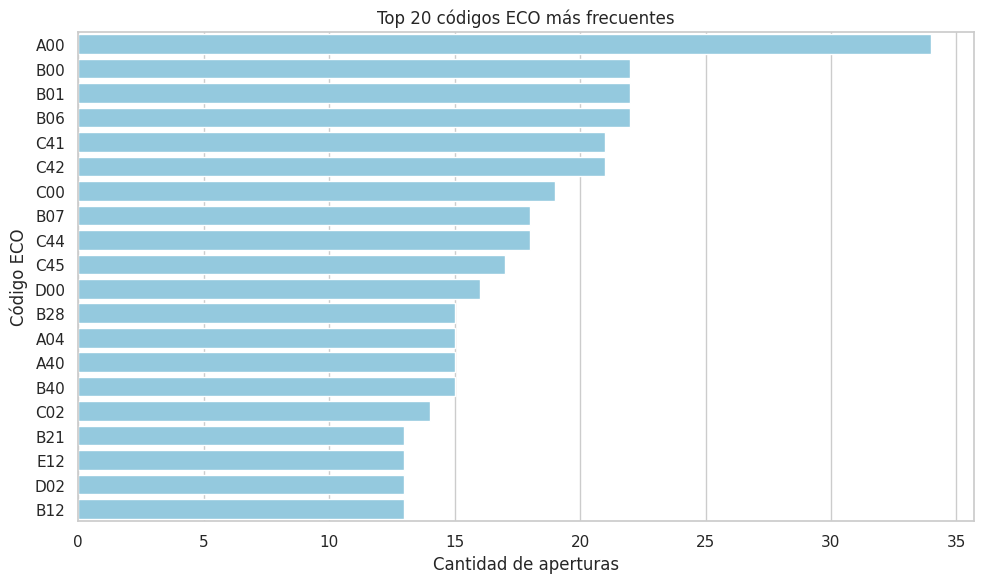

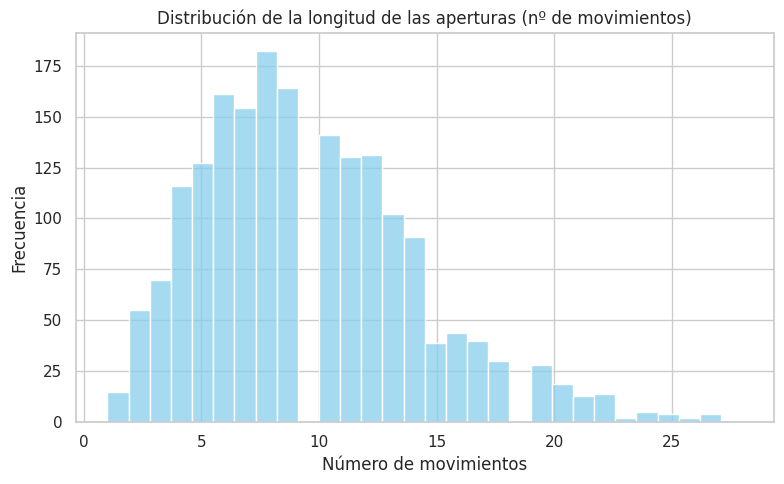

In [ ]:
### 4. GENERACION DE GRAFICOS PARA REGLAS DE ASOCIACION

# Códigos ECO más frecuentes
eco_counts = df['ECO'].value_counts().nlargest(20)
plt.figure(figsize=(10,6))
sns.barplot(x=eco_counts.values, y=eco_counts.index, color="skyblue")
plt.title("Top 20 códigos ECO más frecuentes")
plt.xlabel("Cantidad de aperturas")
plt.ylabel("Código ECO")
plt.tight_layout()
plt.show()

"""
Relación con reglas:
La longitud de apertura está vinculada al análisis de reglas, ya que
los movimientos más frecuentes suelen aparecer en secuencias más largas.
Esto sugiere que las aperturas con estructuras más definidas (más movimientos)
producen patrones repetitivos más detectables.
"""

# Longitud de las secuencias de jugadas
df['longitud'] = df['moves_split'].apply(len)
plt.figure(figsize=(8,5))
sns.histplot(df['longitud'], bins=30, color="skyblue")
plt.title("Distribución de la longitud de las aperturas (nº de movimientos)")
plt.xlabel("Número de movimientos")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

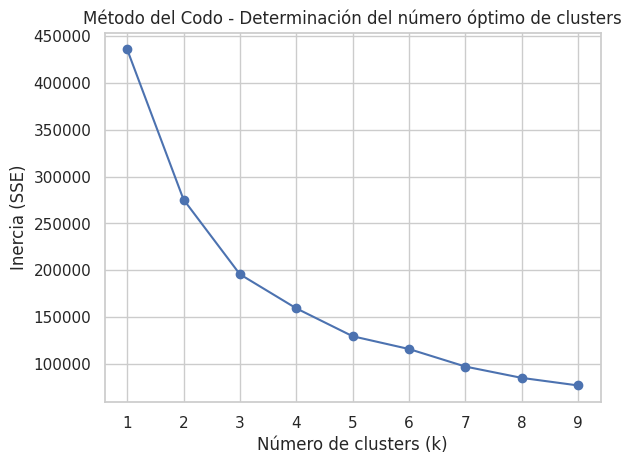


Resumen por cluster:
          Player Win %  Opponent Win %     Draw %
cluster                                         
0           43.467959       28.935142  27.597674
1           28.475153       32.247862  39.278615
2           30.072375       44.549596  25.382391


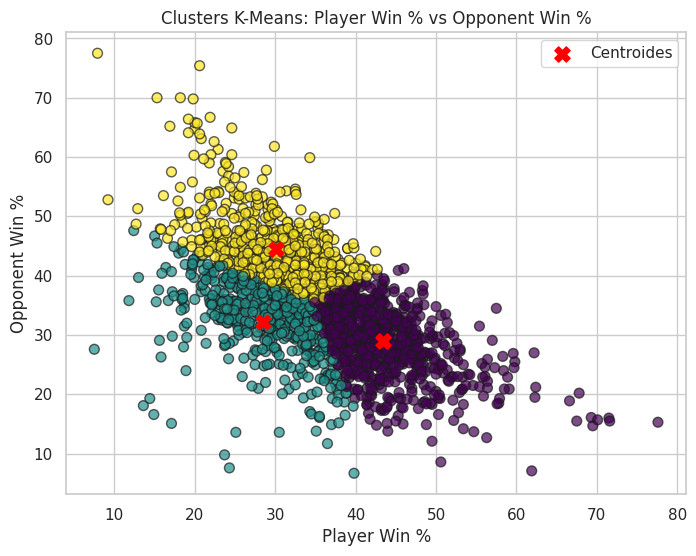

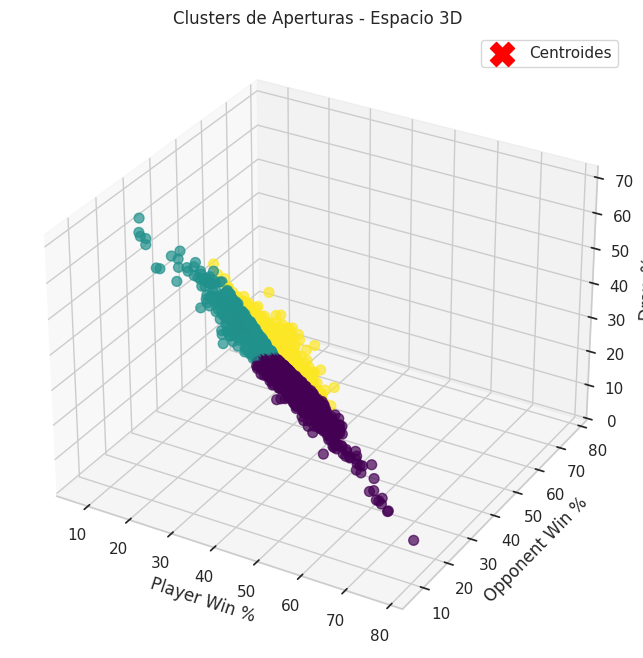

In [ ]:
### 5. CLUSTERING DE APERTURAS

"""
Objetivo del clustering:
Agrupar aperturas según sus resultados estadísticos
para identificar familias con tendencias similares.
Por ejemplo: aperturas que favorecen al blanco, al negro o al empate.

Interpretación de los clusters:
- Cluster 0: predominio de victorias de blancas → aperturas agresivas del primer jugador
- Cluster 1: equilibrio entre victorias y empates → aperturas estables o simétricas
- Cluster 2: ventaja del oponente → defensas efectivas contra e4/d4
"""

# Selección de características
X = df[["Player Win %", "Opponent Win %", "Draw %"]].dropna()

# Método del codo
inertia = []
K_range = range(1, 10)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42).fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker="o")
plt.title("Método del Codo - Determinación del número óptimo de clusters")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inercia (SSE)")
plt.show()

# Aplicar K-Means con k=3
kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

# Resumen por cluster
cluster_summary = df.groupby("cluster")[["Player Win %", "Opponent Win %", "Draw %"]].mean()
print("\nResumen por cluster:\n", cluster_summary)

# Visualización 2D
plt.figure(figsize=(8,6))
plt.scatter(X["Player Win %"], X["Opponent Win %"], c=df["cluster"], cmap="viridis", s=50, alpha=0.7, edgecolor="k")
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c="red", s=120, marker="X", label="Centroides")
plt.title("Clusters K-Means: Player Win % vs Opponent Win %")
plt.xlabel("Player Win %")
plt.ylabel("Opponent Win %")
plt.legend()
plt.show()

# Visualización 3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X["Player Win %"], X["Opponent Win %"], X["Draw %"], c=df["cluster"], cmap="viridis", s=50, alpha=0.7)
ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2], c="red", s=300, marker="X", label="Centroides")
ax.set_xlabel("Player Win %")
ax.set_ylabel("Opponent Win %")
ax.set_zlabel("Draw %")
ax.set_title("Clusters de Aperturas - Espacio 3D")
ax.legend()
plt.show()


**Conclusion General**

El análisis demostró que técnicas descriptivas de minería de datos
(K-Means y reglas de asociación) permiten identificar patrones
estratégicos en aperturas de ajedrez.
Los clusters obtenidos agrupan familias con comportamientos similares,
facilitando un estudio más estructurado del juego.